# ChokePilot — Pipeline Notebook

Wraps the existing pipeline scripts end-to-end: open-loop step test → model
identification → controller demo → Scenarios A/B/C/D. Every cell below calls
into `identify.py`, `controller.py`, `scenarios.py`, `baselines.py`, and
`scenario_d.py` directly — this notebook holds no independent logic, only
orchestration and inline display.

> **NEEDS RE-EXECUTION.** This notebook was structured before Phase A/B/C's final numbers were locked in. Every number, table, and plot below is only as current as the last time this notebook was actually run top-to-bottom -- **re-run all cells once Phase A/B/C's final numbers land**, and do not quote anything from a stale saved output. Each cell calls the same functions the pipeline scripts (`identify.py` / `controller.py` / `scenarios.py` / `baselines.py` / `scenario_d.py`) use, so a fresh run here always matches fresh CLI output -- nothing here is a separate, divergent implementation.


In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "data"))
sys.path.insert(0, str(ROOT))

from simulator import AP_ALARM_BAND  # noqa: E402
from identify import (  # noqa: E402
    run_step_test, plot_step_test, identify_model,
    fit_residual_correction, evaluate_correction, select_beneficial_corrections,
)
from controller import MPCController, safety_limits_from_reference  # noqa: E402
from scenarios import (  # noqa: E402
    solve_choke_for_q, run_scenario, plot_scenario, check_constraints, CSV_PATH, OUTPUT_DIR,
)
from baselines import fixed_choke_setpoint, operator_proxy_setpoint  # noqa: E402
import scenario_d  # noqa: E402

pd.set_option("display.precision", 3)
print("pipeline modules loaded from", ROOT)


pipeline modules loaded from C:\CSE STUFF\College Project\Honeywell Campus connect hackathon\ChokePilot


## 1. Open-Loop Step Test

Fresh monotonic staircase (0→100% choke, 40h dwell/step) against the calibrated simulator — see `identify.py`'s own comments for why 40h, not the originally-tried 24h.

saved C:\CSE STUFF\College Project\Honeywell Campus connect hackathon\ChokePilot\outputs\step_test_response.png


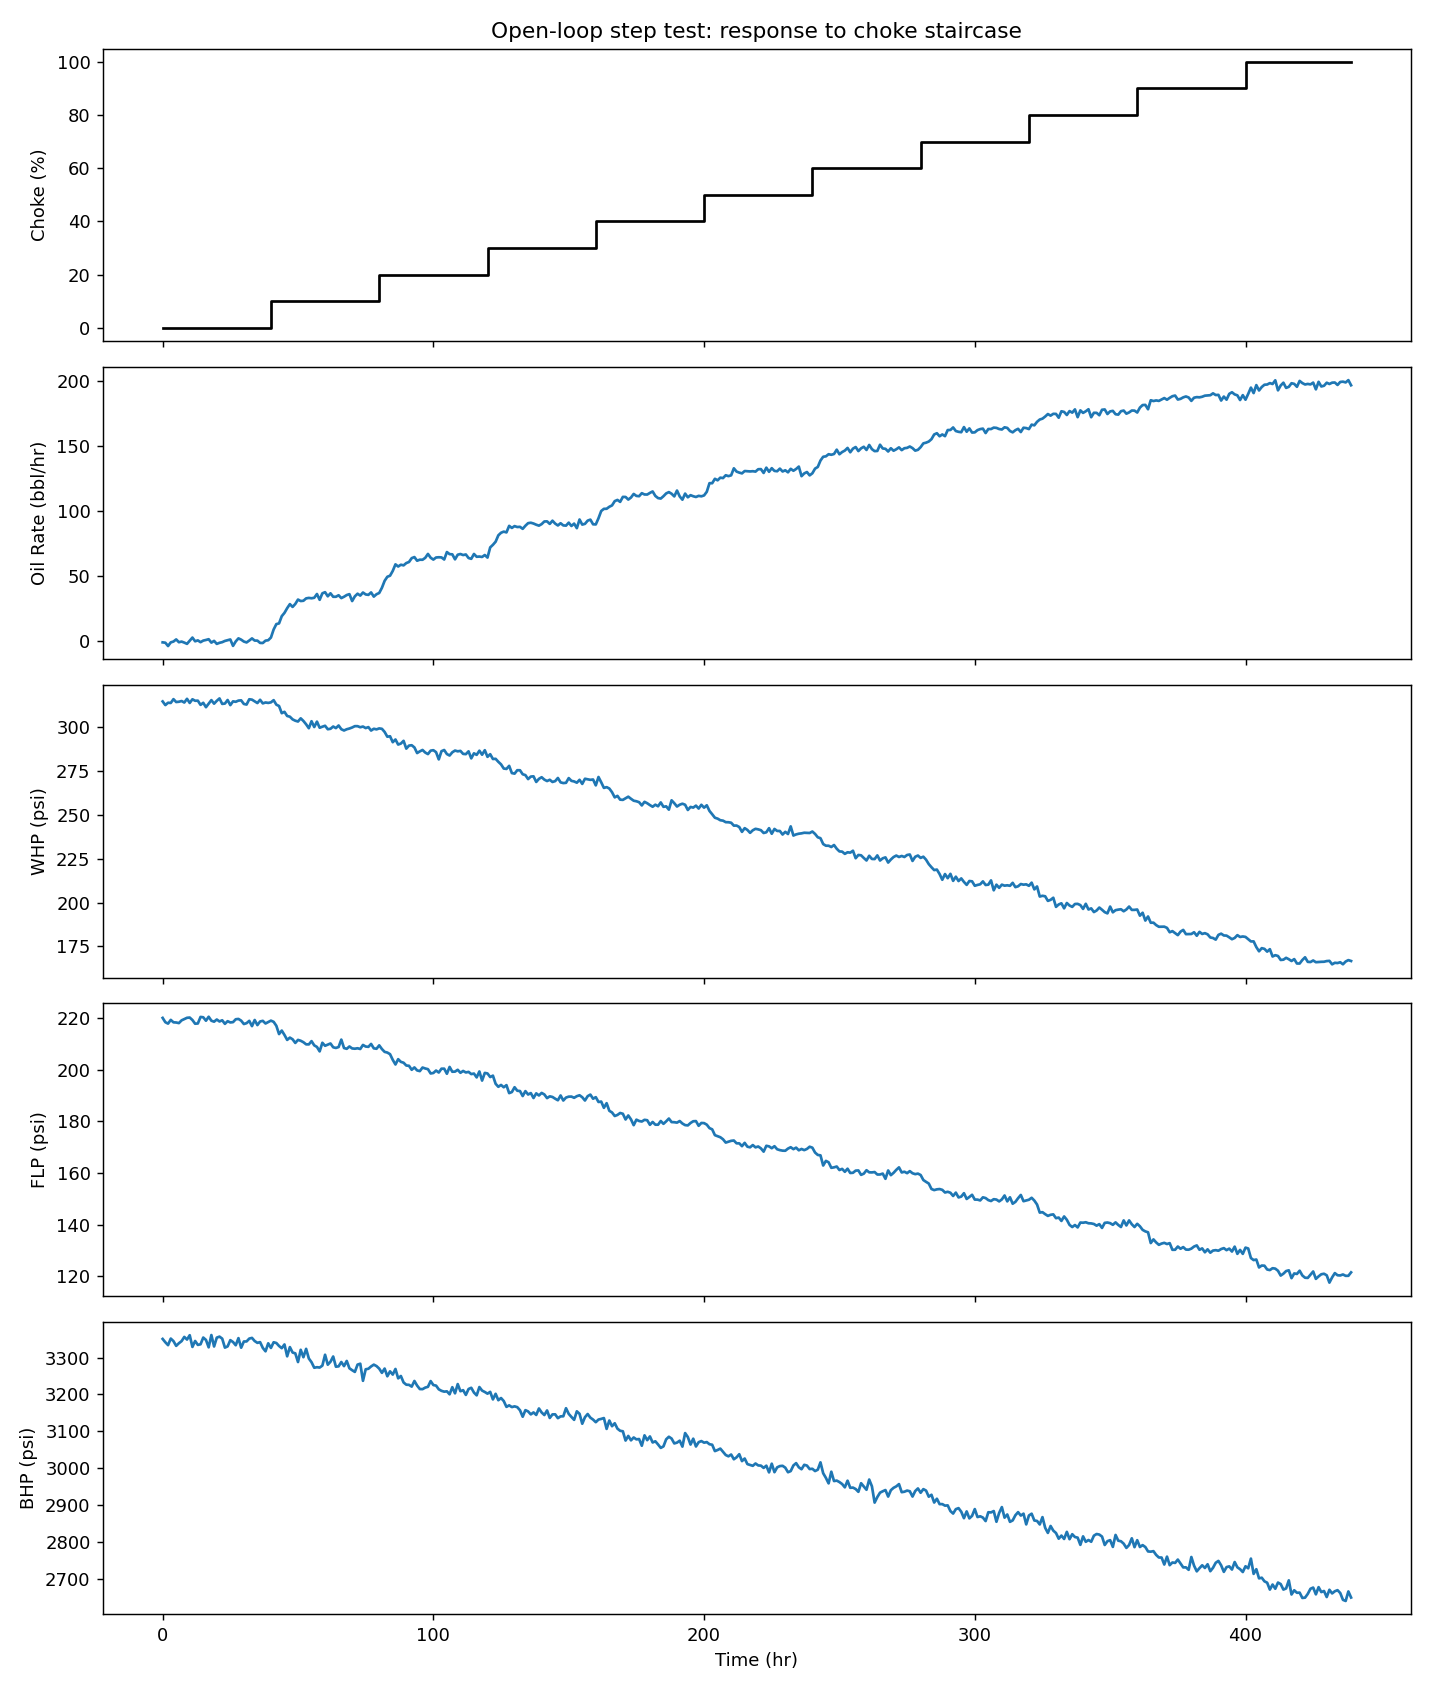

,Time_hr,Choke_pct,Q,WHP,FLP,BHP
0,0,0,-0.843,314.835,220.040,3350.355
1,1,0,-1.107,312.746,218.368,3341.279
2,2,0,-3.657,314.090,217.828,3333.528
3,3,0,-0.856,313.965,219.266,3351.311
4,4,0,-0.202,316.125,218.332,3344.387


In [2]:
step_df = run_step_test(seed=0)
plot_step_test(step_df)
display(Image(filename=str(OUTPUT_DIR / "step_test_response.png")))
step_df.head()


## 2. Model Identification

FOPDT fit per channel (`identify_model`), plus the hybrid physics + learned-correction layer (`fit_residual_correction` → `evaluate_correction` on a held-out step test → `select_beneficial_corrections`, which only keeps a channel's correction if it demonstrably beats physics-only RMSE).

In [3]:
model = identify_model(step_df)
model_summary = pd.DataFrame({
    ch: {"A": p["A"], "B": p["B"], "uh": p["uh"], "tau_h": p["tau"],
         "theta_steps": p["theta_steps"], "noise_std": p["noise_std"]}
    for ch, p in model.items()
}).T
model_summary


,A,B,uh,tau_h,theta_steps,noise_std
Q,0.000,409.812,106.000,4.75,1.0,1.595
WHP,314.407,-60560.070,40705.159,7.25,2.0,1.209
FLP,218.418,-49038.151,50000.000,7.00,1.0,0.888
BHP,3340.508,-340371.863,50000.000,8.75,3.0,10.294


In [4]:
raw_correction = fit_residual_correction(step_df, model)
holdout_df = run_step_test(seed=99)  # different noise draw -- generalization check
correction_report = evaluate_correction(model, raw_correction, holdout_df)
correction = select_beneficial_corrections(raw_correction, correction_report)

report_df = pd.DataFrame(correction_report, index=["rmse_physics_only", "rmse_with_correction"]).T
report_df["kept"] = [correction[ch] is not None for ch in report_df.index]
report_df


,rmse_physics_only,rmse_with_correction,kept
Q,1.662,1.630,True
WHP,1.296,1.304,False
FLP,0.924,0.893,True
BHP,9.848,9.806,True


In [5]:
limits = safety_limits_from_reference(CSV_PATH)
limits


{'WHP': (205.0, inf), 'BHP': (2830.0, inf), 'FLP': (-inf, 200.0)}

## 3. Controller Demo

One-step receding-horizon search (`MPCController.decide`) — both branches: a normal feasible move, and the safety-fallback branch when no candidate clears the envelope. Mirrors `controller.py`'s own `demo()` self-check.

In [6]:
ctrl = MPCController(model, limits, correction=correction)
state = {"Q": 90.0, "WHP": 260.0, "FLP": 185.0, "BHP": 3050.0}

new_u, why = ctrl.decide(state, current_choke=30.0, target_q=150.0)
ctrl.commit(new_u)
assert new_u > 30.0 and new_u - 30.0 <= 5.0 + 1e-9
print("Feasible-move branch:")
print(f"  -> choke {new_u:.1f}%\n  -> {why}")


Feasible-move branch:
  -> choke 35.0%
  -> Moved choke to 35.0% because it keeps WHP/FLP/BHP within safe limits over the next 12h and brings predicted oil rate to 100.9 bbl/hr, the best tradeoff between closing the 150.0 bbl/hr target gap and unnecessary valve movement among 11 feasible options.


In [7]:
impossible_limits = {ch: (1.0e6, 1.0e6 + 0.01) for ch in limits}
ctrl2 = MPCController(model, impossible_limits, correction=correction)
new_u2, why2 = ctrl2.decide(state, current_choke=30.0, target_q=150.0)
ctrl2.commit(new_u2)
assert 0.0 <= new_u2 <= 100.0 and abs(new_u2 - 30.0) <= 5.0 + 1e-9
print("Safety-fallback branch (deliberately impossible limits):")
print(f"  -> choke {new_u2:.1f}%\n  -> {why2}")


Safety-fallback branch (deliberately impossible limits):
  -> choke 25.0%
  -> No choke move keeps all limits satisfied over the lookahead; moved to 25.0% because it minimizes the predicted constraint violation (35957684.4 psi-steps over horizon).


## 4. Scenario A — Startup to Target

15% choke start (inside-but-near-the-edge of the calibrated model's real support band, 30–65% — see `docs/report.md` §2.3), target 100 bbl/hr.

saved C:\CSE STUFF\College Project\Honeywell Campus connect hackathon\ChokePilot\outputs\scenario_A_startup_to_target.png


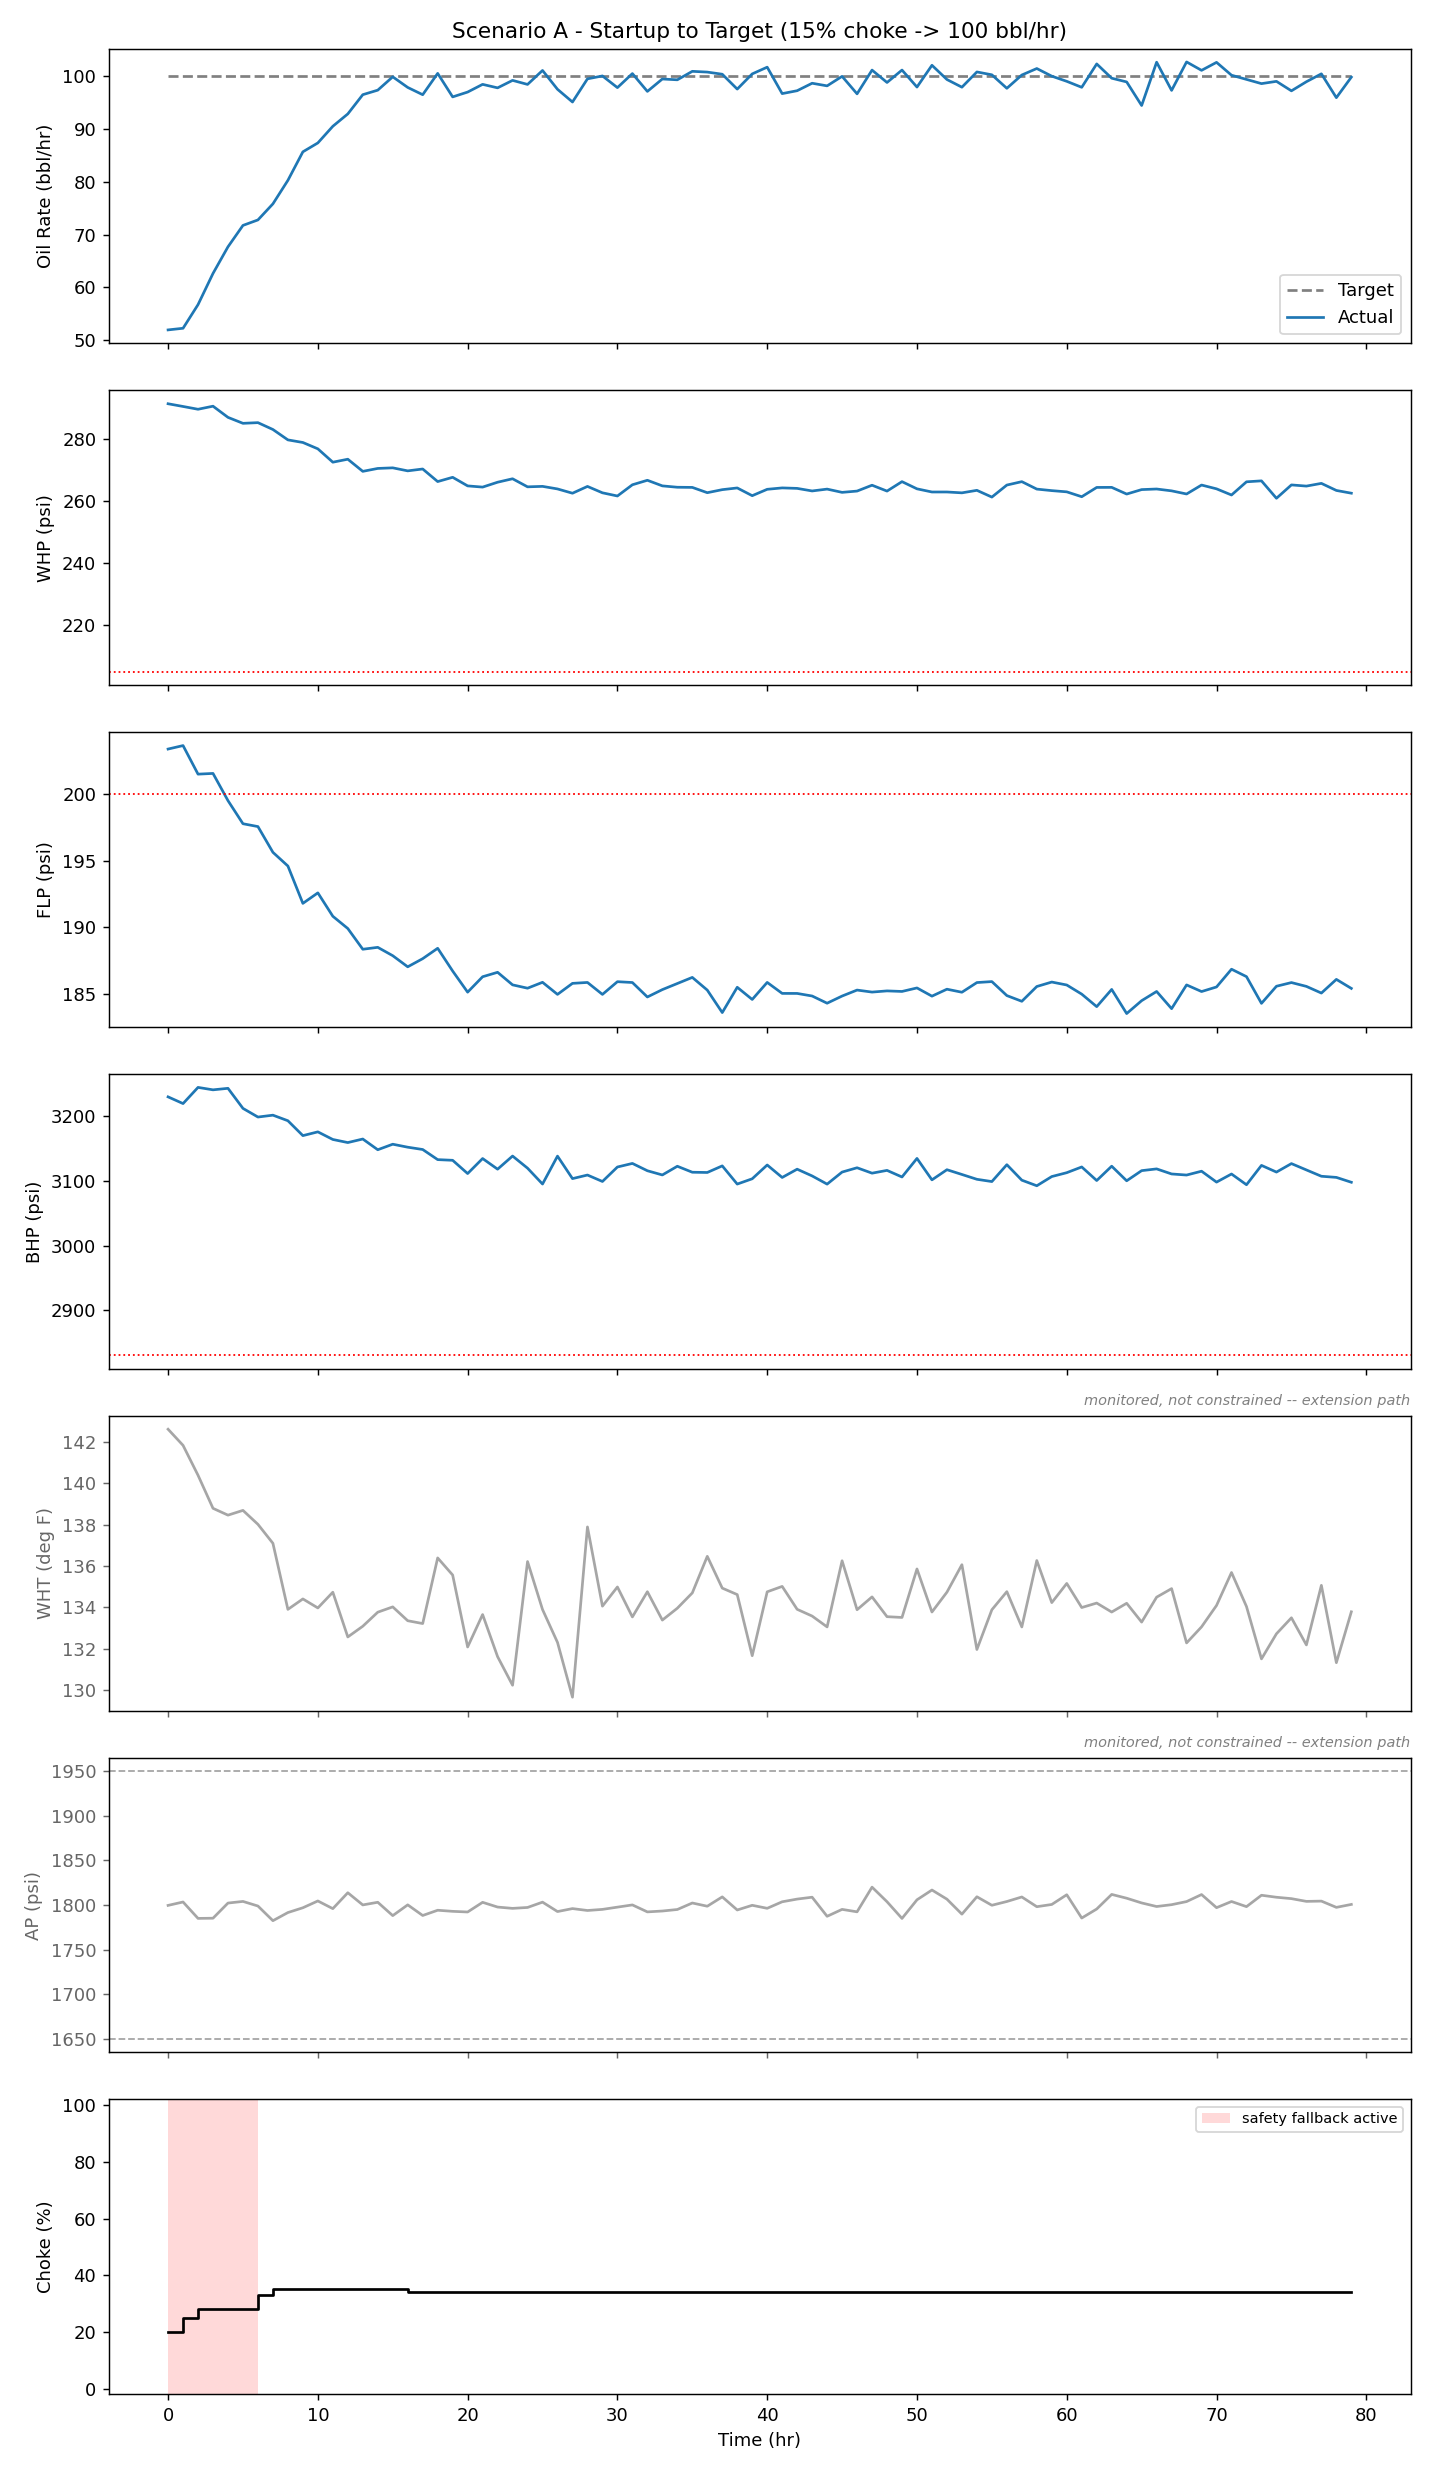

[A_startup_to_target] constraint samples outside limits: 4/80   ramp-rate violations: 0/80
final: target=100.0 actual=99.9 bbl/hr, choke=34.0%
sample decision: Moved choke to 34.0% because it keeps WHP/FLP/BHP within safe limits over the next 12h and brings predicted oil rate to 99.3 bbl/hr, the best tradeoff between closing the 100.0 bbl/hr target gap and unnecessary valve movement among 11 feasible options.


In [8]:
df_a = run_scenario("A_startup_to_target", 15.0, lambda t: 100.0, 80, model, limits, sim_seed=10, correction=correction)
plot_scenario("A_startup_to_target", "Scenario A - Startup to Target (15% choke -> 100 bbl/hr)", df_a, limits)
display(Image(filename=str(OUTPUT_DIR / "scenario_A_startup_to_target.png")))
check_constraints("A_startup_to_target", df_a, limits)
print(f"final: target={df_a.Target_Q.iloc[-1]:.1f} actual={df_a.Q.iloc[-1]:.1f} bbl/hr, choke={df_a.Choke.iloc[-1]:.1f}%")
print(f"sample decision: {df_a.Why.iloc[-1]}")


## 5. Scenario B — Target Tracking

Starts at the choke the identified model itself says holds ~100 bbl/hr steady-state; target steps 100 → 150 bbl/hr at t=60h.

saved C:\CSE STUFF\College Project\Honeywell Campus connect hackathon\ChokePilot\outputs\scenario_B_target_tracking.png


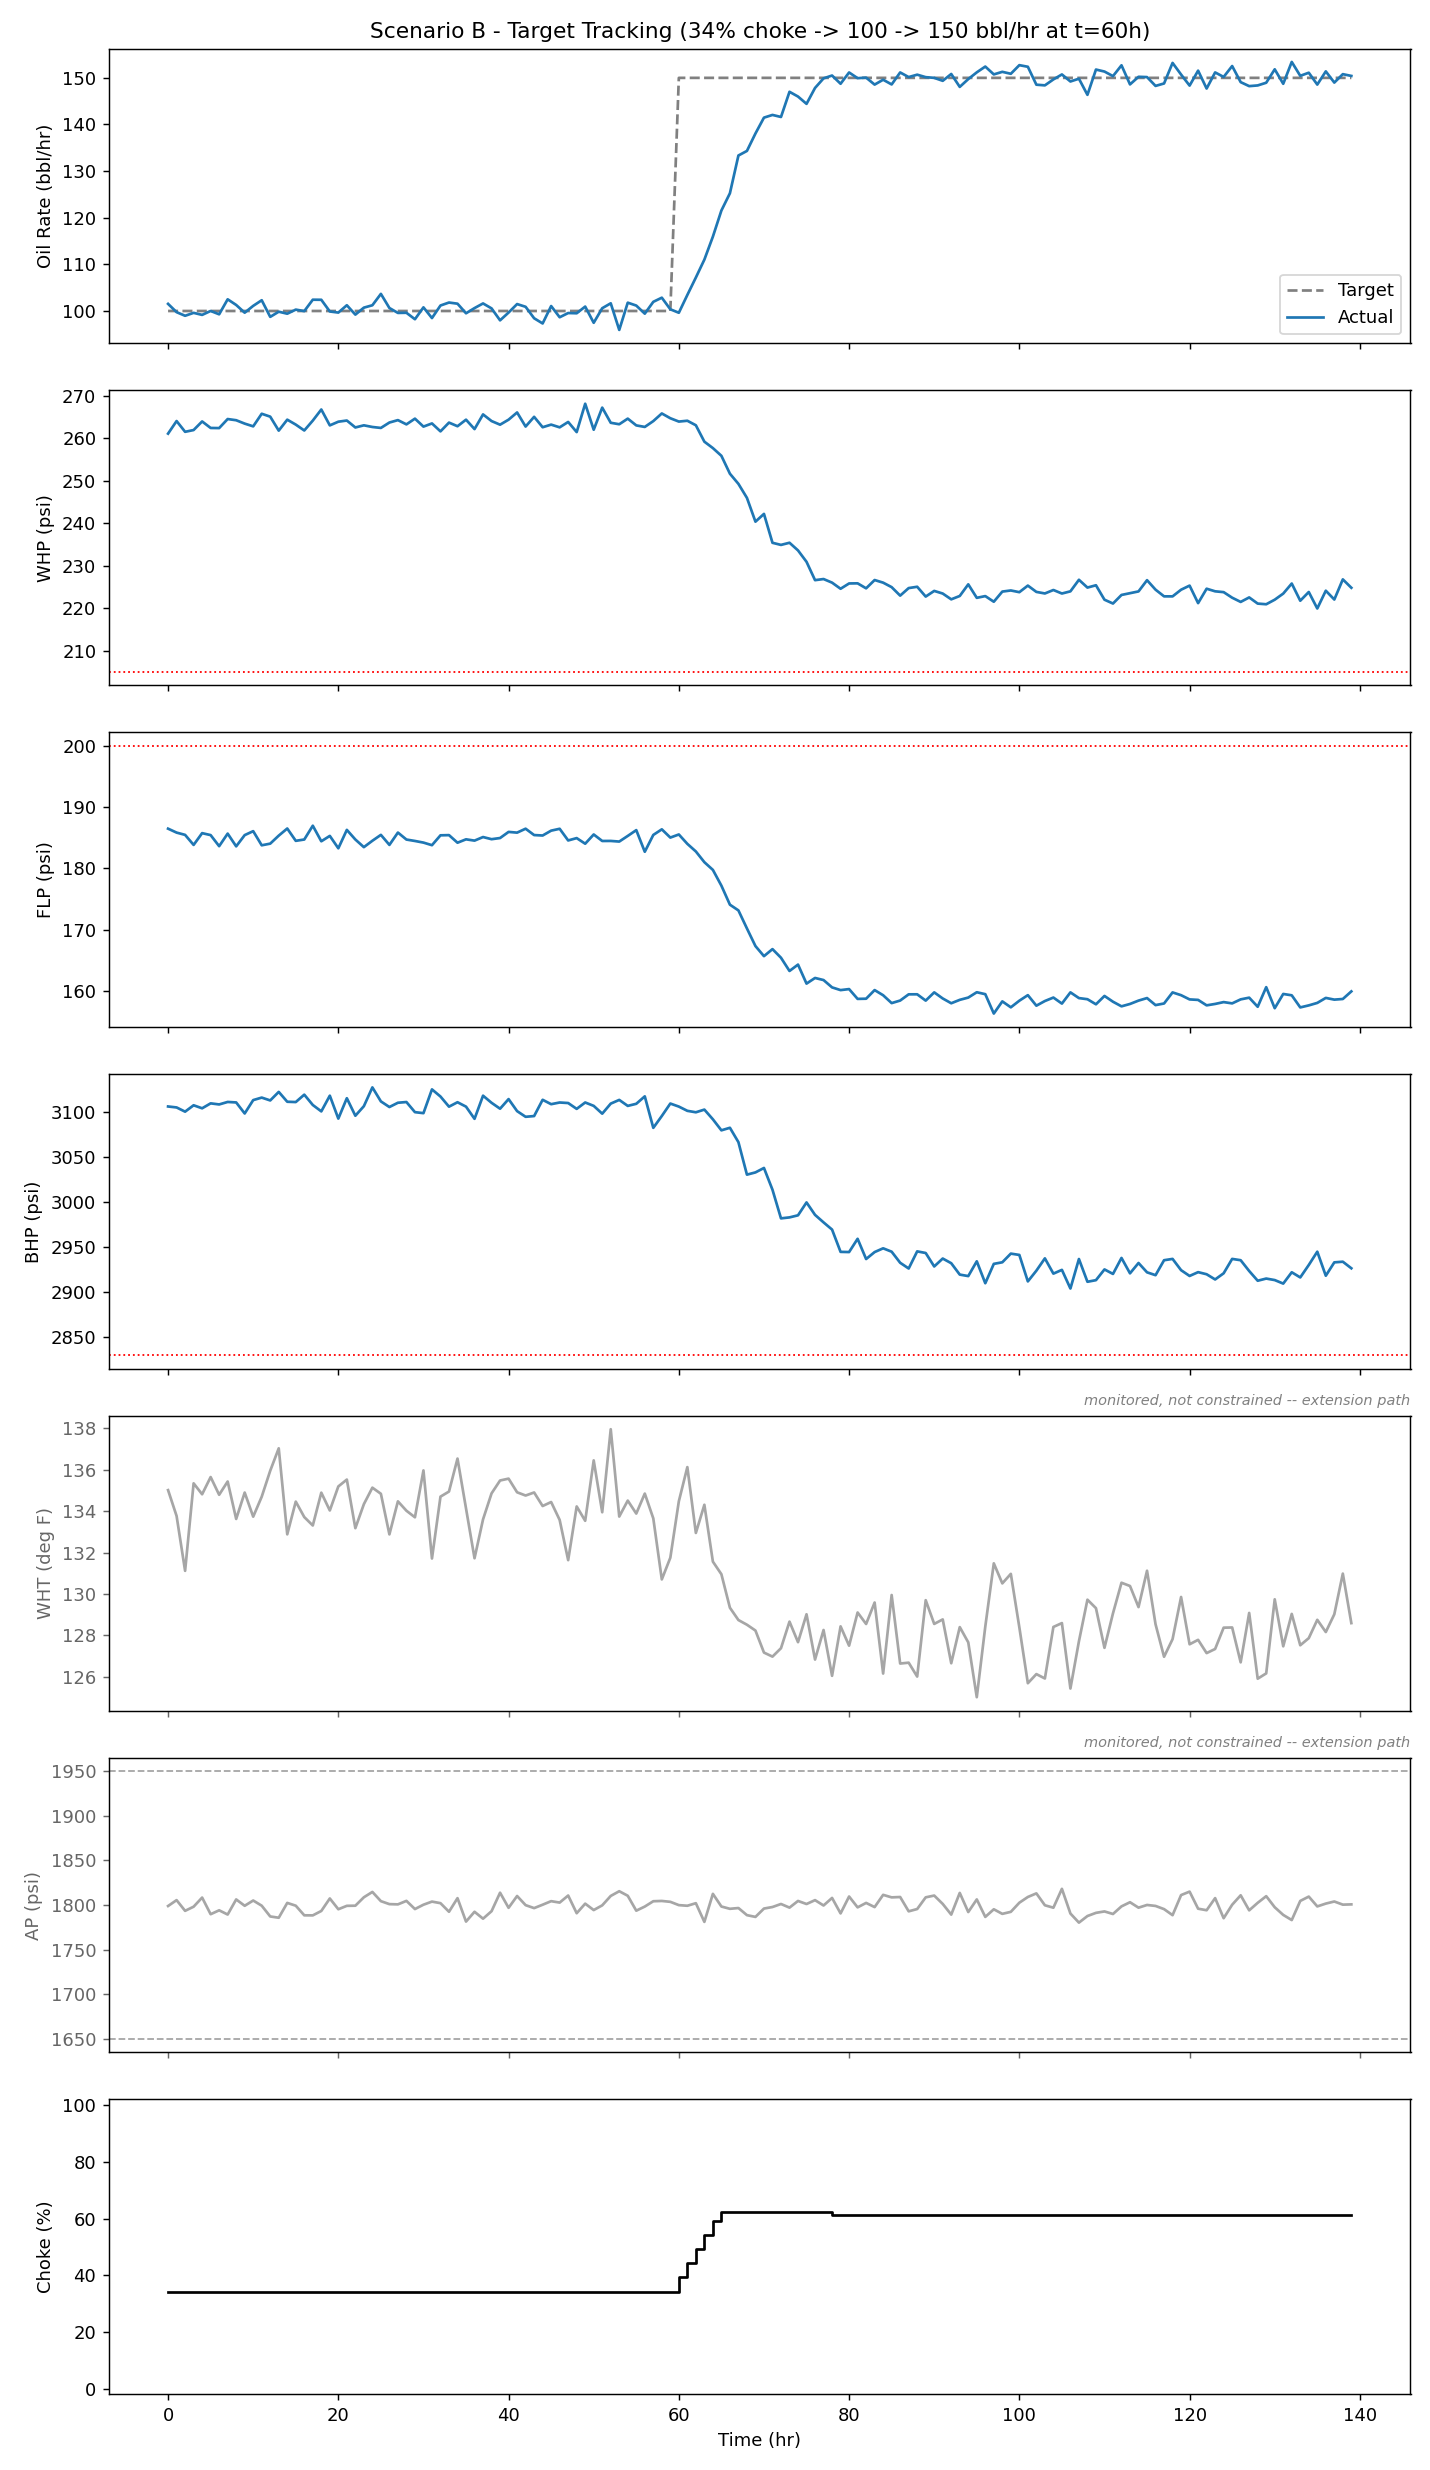

[B_target_tracking] constraint samples outside limits: 0/140   ramp-rate violations: 0/140
final: target=150.0 actual=150.4 bbl/hr, choke=61.2%
sample decision: Moved choke to 61.2% because it keeps WHP/FLP/BHP within safe limits over the next 12h and brings predicted oil rate to 149.9 bbl/hr, the best tradeoff between closing the 150.0 bbl/hr target gap and unnecessary valve movement among 11 feasible options.


In [9]:
u_stable_100 = solve_choke_for_q(model, 100.0)
target_fn_b = lambda t: 100.0 if t < 60 else 150.0
df_b = run_scenario("B_target_tracking", u_stable_100, target_fn_b, 140, model, limits, sim_seed=11, correction=correction)
plot_scenario("B_target_tracking",
              f"Scenario B - Target Tracking ({u_stable_100:.0f}% choke -> 100 -> 150 bbl/hr at t=60h)",
              df_b, limits)
display(Image(filename=str(OUTPUT_DIR / "scenario_B_target_tracking.png")))
check_constraints("B_target_tracking", df_b, limits)
print(f"final: target={df_b.Target_Q.iloc[-1]:.1f} actual={df_b.Q.iloc[-1]:.1f} bbl/hr, choke={df_b.Choke.iloc[-1]:.1f}%")
print(f"sample decision: {df_b.Why.iloc[-1]}")


## 6. Scenario C — Infeasible Target

Same stable start as B, but the 400 bbl/hr target deliberately exceeds what's safely achievable — the controller should settle at the maximum safe rate instead of chasing it.

saved C:\CSE STUFF\College Project\Honeywell Campus connect hackathon\ChokePilot\outputs\scenario_C_infeasible_target.png


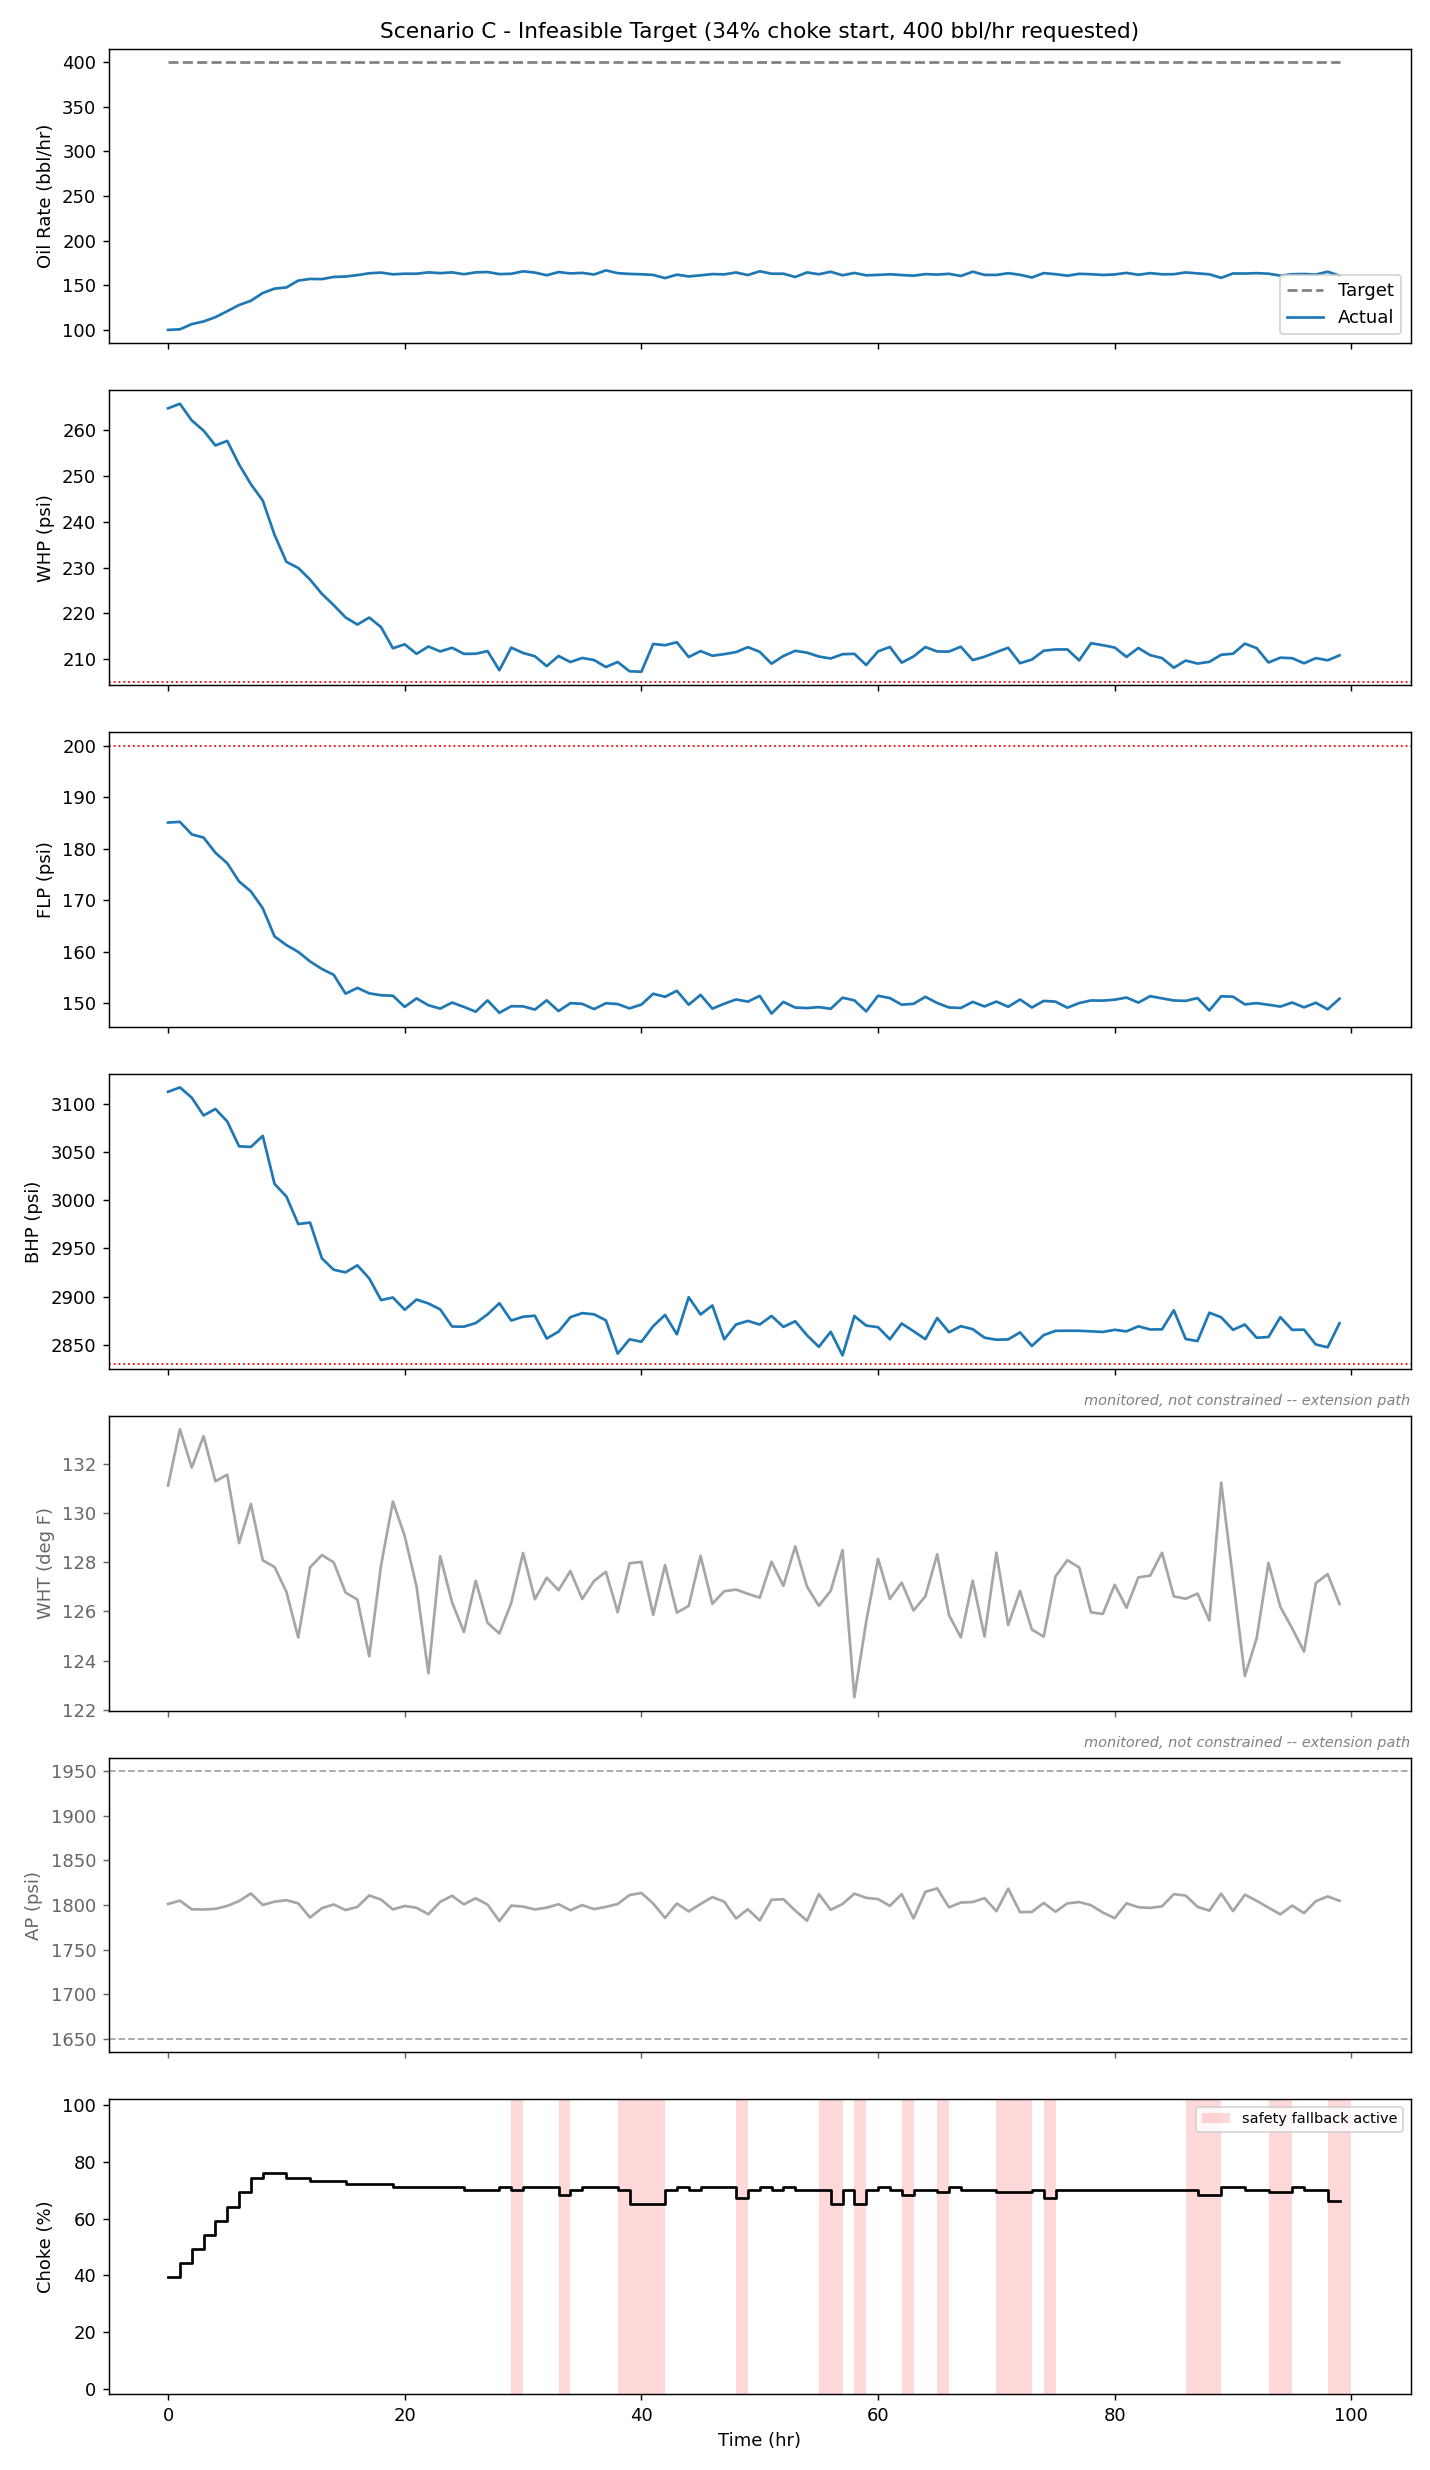

[C_infeasible_target] constraint samples outside limits: 0/100   ramp-rate violations: 0/100
final: target=400.0 actual=160.8 bbl/hr, choke=66.2%
sample decision: No choke move keeps all limits satisfied over the lookahead; moved to 66.2% because it minimizes the predicted constraint violation (28.8 psi-steps over horizon).


In [10]:
df_c = run_scenario("C_infeasible_target", u_stable_100, lambda t: 400.0, 100, model, limits, sim_seed=12, correction=correction)
plot_scenario("C_infeasible_target",
              f"Scenario C - Infeasible Target ({u_stable_100:.0f}% choke start, 400 bbl/hr requested)",
              df_c, limits)
display(Image(filename=str(OUTPUT_DIR / "scenario_C_infeasible_target.png")))
check_constraints("C_infeasible_target", df_c, limits)
print(f"final: target={df_c.Target_Q.iloc[-1]:.1f} actual={df_c.Q.iloc[-1]:.1f} bbl/hr, choke={df_c.Choke.iloc[-1]:.1f}%")
print(f"sample decision: {df_c.Why.iloc[-1]}")


## 7. Scenario D — Disturbance Rejection

Relaxes the brief's "no changing reservoir properties" simplification on purpose: BHP's identified steady-state offset drifts -0.5 psi/h for 200h (a slow reservoir decline) while target stays fixed at 100 bbl/hr. Compares MPC (re-measures and re-plans every hour) against two baselines held at a static setpoint (`baselines.py`'s Fixed-optimal and Fixed-operator-proxy) — same drifting plant, same noise seed, only the strategy differs. See `scenario_d.py` for the full setup.

start choke: 34.2%   Fixed-optimal setpoint: 34.2%   Fixed-operator-proxy setpoint: 18.7%


saved C:\CSE STUFF\College Project\Honeywell Campus connect hackathon\ChokePilot\outputs\scenario_D_disturbance_rejection.png


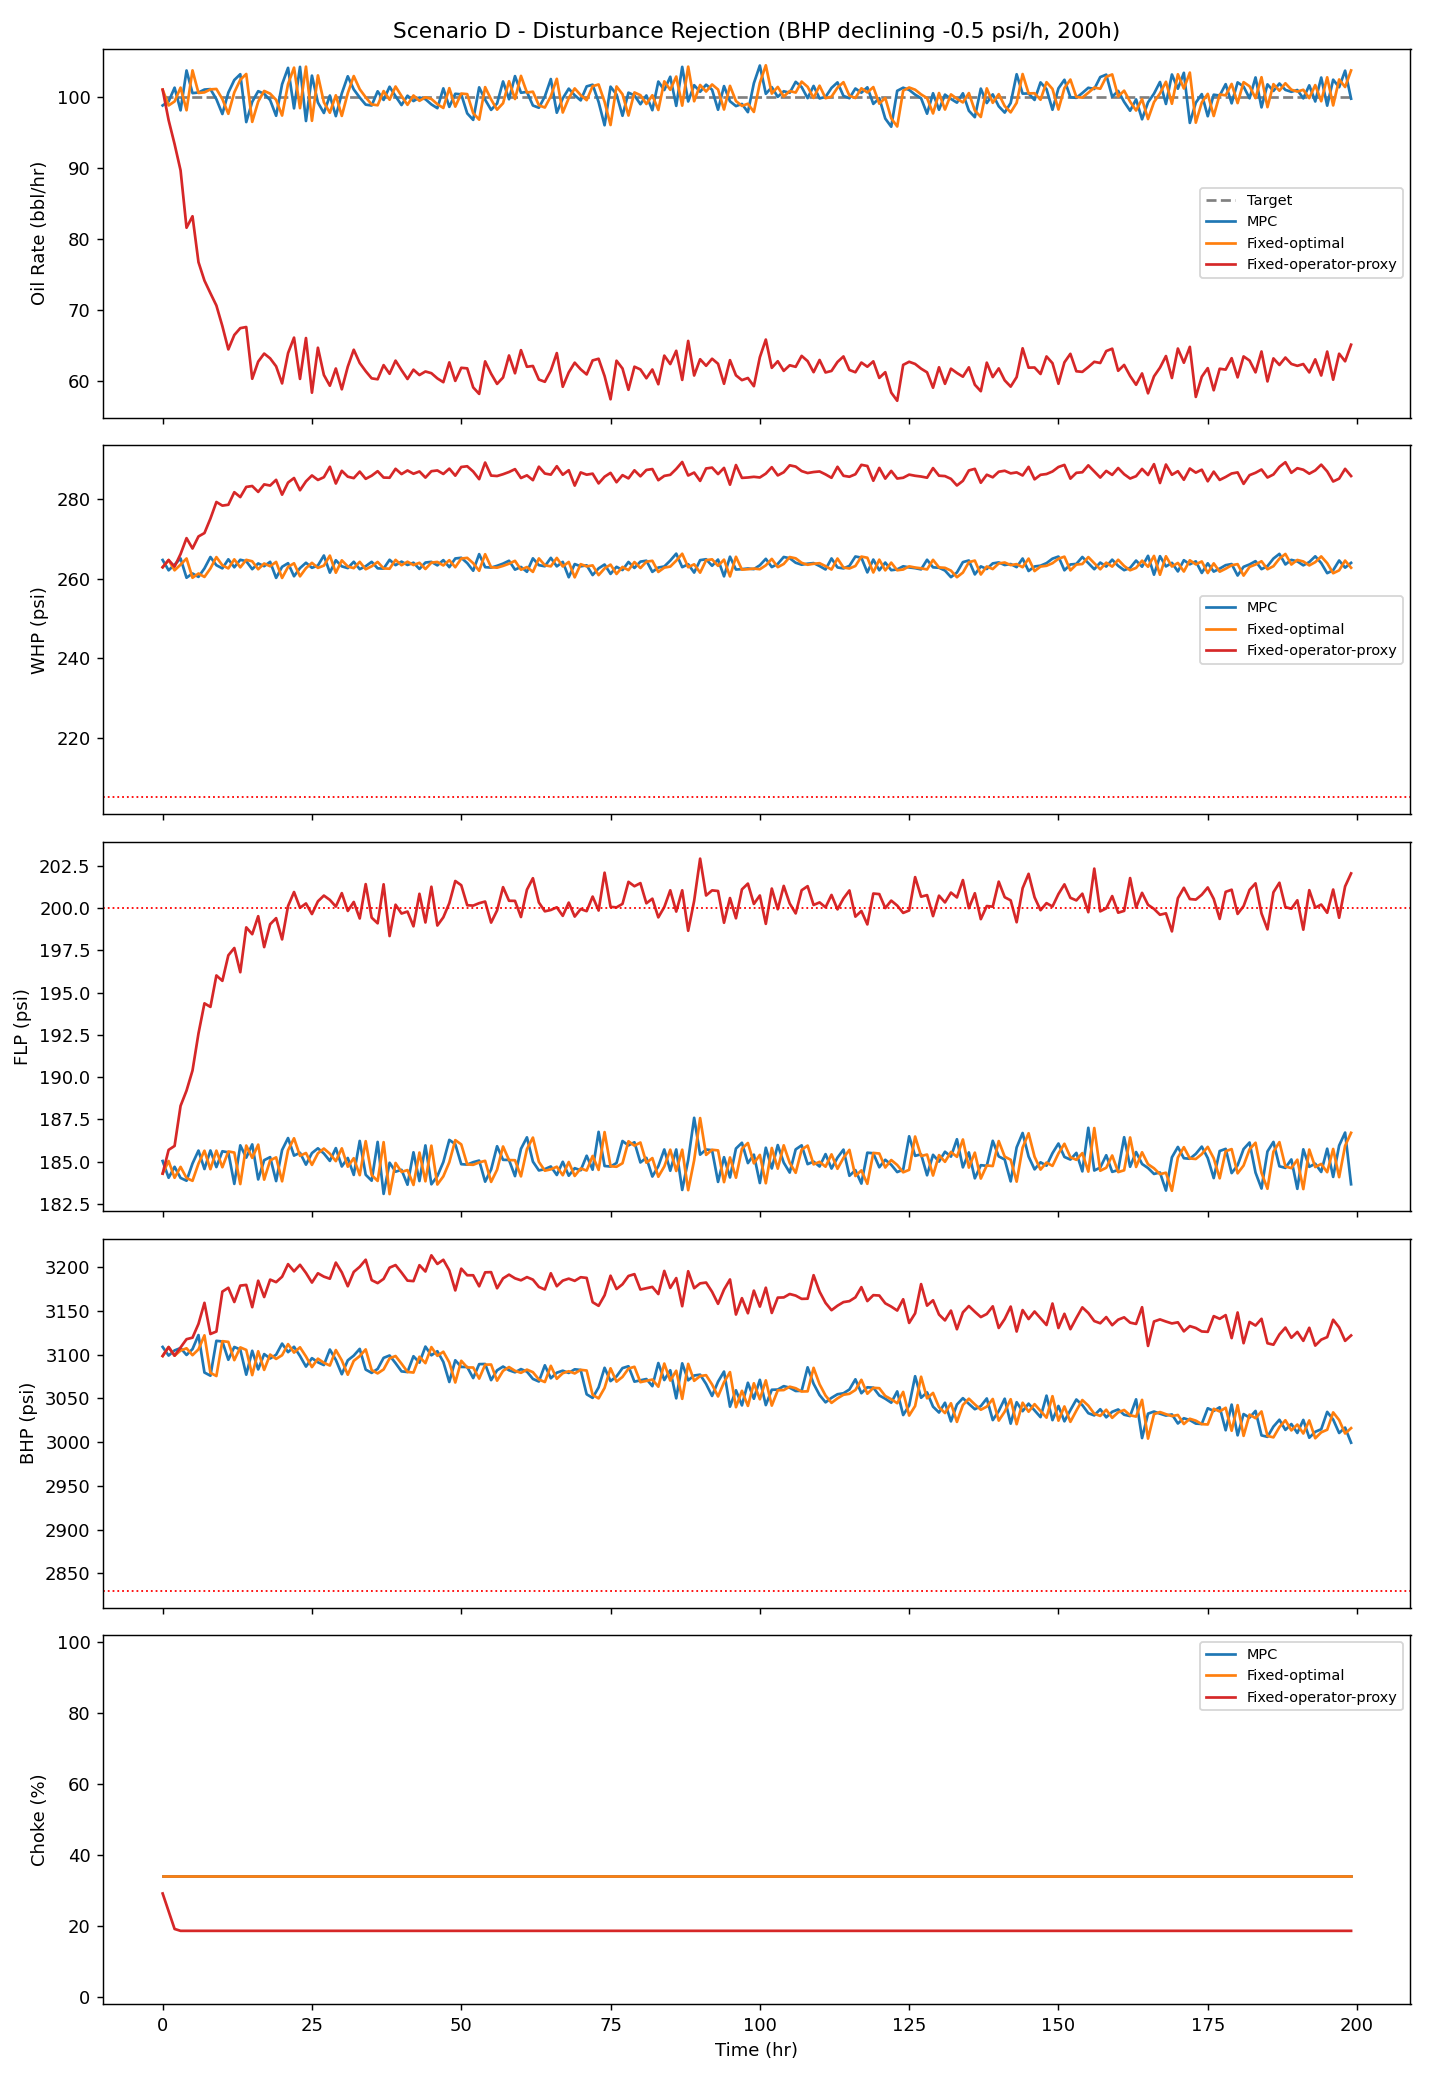

[D_MPC] constraint samples outside limits: 0/200   ramp-rate violations: 0/200
[D_Fixed-optimal] constraint samples outside limits: 0/200   ramp-rate violations: 0/200
[D_Fixed-operator-proxy] constraint samples outside limits: 121/200   ramp-rate violations: 0/200


,violations,total_barrels,time_to_first_violation_h
approach,,,
MPC,0,20040.903,never
Fixed-optimal,0,20048.256,never
Fixed-operator-proxy,121,12594.195,21.0


In [11]:
tightened = ctrl.limits  # MPCController's own noise-tightened envelope, reused so the
                          # fixed baselines are held to the same standard as the MPC
start_choke_d = solve_choke_for_q(model, scenario_d.TARGET_Q)
seed_d = 20

optimal_setpoint = fixed_choke_setpoint(model, correction, tightened, scenario_d.TARGET_Q)
operator_setpoint = operator_proxy_setpoint(CSV_PATH, scenario_d.TARGET_Q)
print(f"start choke: {start_choke_d:.1f}%   Fixed-optimal setpoint: {optimal_setpoint:.1f}%   "
      f"Fixed-operator-proxy setpoint: {operator_setpoint:.1f}%")

runs = {
    "MPC": scenario_d.run_mpc(model, limits, correction, start_choke_d, sim_seed=seed_d),
    "Fixed-optimal": scenario_d.run_fixed(optimal_setpoint, start_choke_d, sim_seed=seed_d),
    "Fixed-operator-proxy": scenario_d.run_fixed(operator_setpoint, start_choke_d, sim_seed=seed_d),
}
scenario_d.plot_comparison(runs, limits, OUTPUT_DIR / "scenario_D_disturbance_rejection.png")
display(Image(filename=str(OUTPUT_DIR / "scenario_D_disturbance_rejection.png")))

rows = []
for label, df in runs.items():
    viol, _ = check_constraints(f"D_{label}", df, limits)
    t_first = scenario_d.time_to_first_violation(df, limits)
    rows.append({"approach": label, "violations": viol, "total_barrels": float(df.Q.sum()),
                 "time_to_first_violation_h": t_first if t_first is not None else "never"})
pd.DataFrame(rows).set_index("approach")


## Notes

- Full narrative writeup, honest limitations, and the 30-seed statistical sweep live in `docs/report.md` — this notebook is the runnable companion, not a replacement.
- WHT/AP (Wellhead Temperature, Annulus Pressure) are monitored-but-not-constrained extension channels — see `data/simulator.py`'s module docstring — plotted (greyed out) inside each `plot_scenario` figure above, not analyzed separately here.

> **NEEDS RE-EXECUTION.** This notebook was structured before Phase A/B/C's final numbers were locked in. Every number, table, and plot below is only as current as the last time this notebook was actually run top-to-bottom -- **re-run all cells once Phase A/B/C's final numbers land**, and do not quote anything from a stale saved output. Each cell calls the same functions the pipeline scripts (`identify.py` / `controller.py` / `scenarios.py` / `baselines.py` / `scenario_d.py`) use, so a fresh run here always matches fresh CLI output -- nothing here is a separate, divergent implementation.
